<a href="https://colab.research.google.com/github/ajinfajrian/data-science-2026/blob/master/Pertemuan7_Fajrian_Ichlasul_240401020100.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SEL 1: Memuat Data dan Preprocessing Cepat

Instruksi Modul: Load data Titanic, pilih kolom numerik penunjang, lakukan imputasi pada data yang kosong, lalu pisahkan target (fare) dan fitur independen (X).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Load data resmi via Seaborn
df_raw = sns.load_dataset('titanic')

# 2. Mengambil kolom fitur numerik untuk eksperimen regresi linear
cols = ['pclass', 'age', 'sibsp', 'parch', 'fare']
df = df_raw[cols].copy()

# 3. Imputasi nilai kosong pada kolom 'age' menggunakan median
df['age'] = df['age'].fillna(df['age'].median())

# 4. Menentukan Fitur (X) dan Target kontinu (y) untuk prediksi tarif tiket
X = df.drop('fare', axis=1)
y = df['fare']

print("--- Pengecekan Kesiapan Data Regresi ---")
print(f"Dimensi Fitur X: {X.shape} | Dimensi Target y: {y.shape}")
print(f"Jumlah data kosong di dataset: {df.isnull().sum().sum()}")

--- Pengecekan Kesiapan Data Regresi ---
Dimensi Fitur X: (891, 4) | Dimensi Target y: (891,)
Jumlah data kosong di dataset: 0


SEL 2: Train-Test Split (Pembagian Data)

Instruksi Modul: Membagi data menjadi 80% Train untuk melatih pemodelan matematika Regresi, dan 20% Test untuk menguji akurasi hasil prediksi.

In [2]:
# Membagi dataset dengan rasio 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Jumlah Data Latih (Train): {X_train.shape[0]} baris")
print(f"Jumlah Data Uji (Test)   : {X_test.shape[0]} baris")

Jumlah Data Latih (Train): 712 baris
Jumlah Data Uji (Test)   : 179 baris


SEL 3: Model Training (Pelatihan Regresi Linear)

Instruksi Modul: Melakukan inisialisasi objek algoritma LinearRegression dari Scikit-Learn dan melatihnya menggunakan data latih (.fit()).

In [4]:
# 1. Inisialisasi Model
model = LinearRegression()

# 2. Melatih model matematika dengan data latih
model.fit(X_train, y_train)

print("Proses training model Regresi Linear selesai!")
print(f"Intercept (Konstanta garis b0)  : {model.intercept_.round(3)}")
print(f"Coefficients (Koefisien b1..bn) : {model.coef_.round(3)}")

Proses training model Regresi Linear selesai!
Intercept (Konstanta garis b0)  : 113.751
Coefficients (Koefisien b1..bn) : [-36.026  -0.149   5.256  11.157]


SEL 4: Model Prediction & Evaluasi Metrik Statistik

Instruksi Modul: Melakukan prediksi pada data uji (X_test), lalu menghitung performa ketepatan model menggunakan metrik standar regresi: MAE, MSE, RMSE, dan R-Squared (R2).

In [5]:
# 1. Melakukan prediksi terhadap data test yang belum pernah dilihat model
y_pred = model.predict(X_test)

# 2. Menghitung metrik evaluasi regresi
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("--- Hasil Evaluasi Performa Model Regresi ---")
print(f"Mean Absolute Error (MAE)  : {mae:.3f} (Rata-rata selisih absolut prediksi)")
print(f"Mean Squared Error (MSE)   : {mse:.3f}")
print(f"Root Mean Squared Error(RMSE): {rmse:.3f} (Penalti untuk error besar)")
print(f"R-Squared (R²) Score       : {r2:.3f} (Persentase varians yang mampu dijelaskan model)")

--- Hasil Evaluasi Performa Model Regresi ---
Mean Absolute Error (MAE)  : 19.782 (Rata-rata selisih absolut prediksi)
Mean Squared Error (MSE)   : 946.336
Root Mean Squared Error(RMSE): 30.763 (Penalti untuk error besar)
R-Squared (R²) Score       : 0.388 (Persentase varians yang mampu dijelaskan model)


SEL 5: Visualisasi Evaluasi Proyek (Actual vs Predicted & Residual Plot)

Instruksi Modul: Membuat dua buah grafik evaluasi secara berdampingan untuk melihat seberapa dekat titik sebaran prediksi dengan garis lurus ideal, serta memeriksa apakah sisa error (residuals) tersebar secara acak.

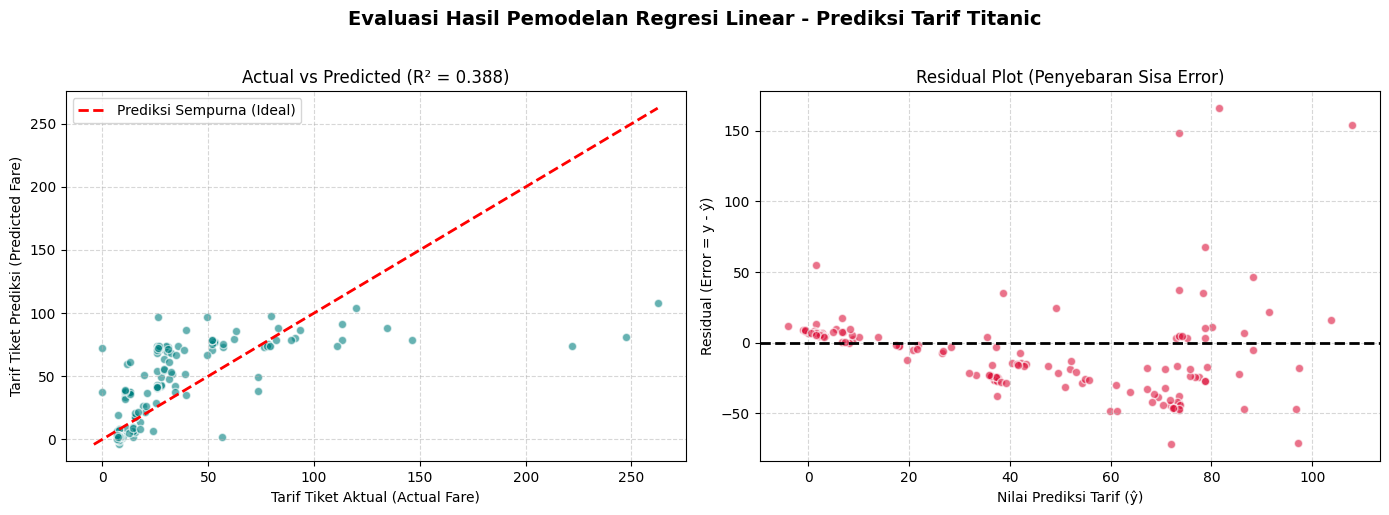

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Scatter Plot Data Aktual vs Hasil Prediksi
axes[0].scatter(y_test, y_pred, alpha=0.6, color='teal', edgecolors='w')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2, label='Prediksi Sempurna (Ideal)')
axes[0].set_xlabel('Tarif Tiket Aktual (Actual Fare)')
axes[0].set_ylabel('Tarif Tiket Prediksi (Predicted Fare)')
axes[0].set_title(f'Actual vs Predicted (R² = {r2:.3f})', fontsize=12)
axes[0].legend()

# Plot 2: Residual Plot (Sisa Error)
residuals = y_test - y_pred
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[1].scatter(y_pred, residuals, alpha=0.6, color='crimson', edgecolors='w')
axes[1].axhline(0, color='black', linestyle='--', lw=2)
axes[1].set_xlabel('Nilai Prediksi Tarif (ŷ)')
axes[1].set_ylabel('Residual (Error = y - ŷ)')
axes[1].set_title('Residual Plot (Penyebaran Sisa Error)', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Evaluasi Hasil Pemodelan Regresi Linear - Prediksi Tarif Titanic', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()